# Benchmark 分析

用于加载 `train.py` 的训练产物并做基础评估分析。

In [12]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

ARTIFACT_DIR = Path('./artifacts')
META_PATH = ARTIFACT_DIR / 'run_metadata.json'
PRED_DIR = ARTIFACT_DIR / 'predictions'

In [13]:
with META_PATH.open('r', encoding='utf-8') as f:
    metadata = json.load(f)

df_train = pd.read_csv(PRED_DIR / 'train_predictions.csv')
df_val = pd.read_csv(PRED_DIR / 'val_predictions.csv')
df_test = pd.read_csv(PRED_DIR / 'test_predictions.csv')

print('model_path:', metadata.get('model_path', ''))
print('rows:', {k: len(v) for k, v in {'train': df_train, 'val': df_val, 'test': df_test}.items()})
df_test.head(3)

model_path: artifacts/models/best_model.pt
rows: {'train': 59191, 'val': 19731, 'test': 19731}


,sn,verify_time,target,split,prob,score
0,EDD20260215051936219K0W8d,1771107581,1,test,0.693158,540.165552
1,EDD202602150520337gw72Ipm,1771107638,0,test,0.479437,566.053922
2,EDD20260215052341JQSoOh52,1771107830,1,test,0.787991,525.798217


In [14]:
def calc_metrics(df):
    y_true = df['target'].to_numpy()
    y_prob = df['prob'].to_numpy()
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return {
        'rows': len(df),
        'bad_rate': float(df['target'].mean()),
        'auc': float(roc_auc_score(y_true, y_prob)),
        'pr_auc': float(average_precision_score(y_true, y_prob)),
        'ks': float(np.max(tpr - fpr)),
        'score_min': float(df['score'].min()),
        'score_max': float(df['score'].max()),
    }

report = pd.DataFrame({
    'train': calc_metrics(df_train),
    'val': calc_metrics(df_val),
    'test': calc_metrics(df_test),
}).T

report

,rows,bad_rate,auc,pr_auc,ks,score_min,score_max
train,59191.0,0.216503,0.694206,0.374458,0.285216,516.065782,621.793633
val,19731.0,0.216512,0.688107,0.377779,0.274580,515.965839,620.287681
test,19731.0,0.235720,0.670859,0.369490,0.252387,517.092484,620.925561


In [15]:
def decile_report(df, score_col='score', target_col='target', q=10):
    tmp = df[[score_col, target_col]].copy()
    tmp['decile'] = pd.qcut(tmp[score_col], q=q, duplicates='drop')
    out = tmp.groupby('decile', observed=False).agg(
        rows=(target_col, 'size'),
        bads=(target_col, 'sum'),
        bad_rate=(target_col, 'mean'),
        score_min=(score_col, 'min'),
        score_max=(score_col, 'max'),
    ).reset_index()
    return out

test_decile = decile_report(df_test, q=10)
test_decile

,decile,rows,bads,bad_rate,score_min,score_max
0,"(517.091, 537.278]",1974,890,0.450861,517.092484,537.278082
1,"(537.278, 544.748]",1973,687,0.348201,537.279606,544.748401
2,"(544.748, 551.626]",1973,599,0.303599,544.751712,551.626098
3,"(551.626, 557.659]",1973,539,0.273188,551.626544,557.658573
4,"(557.659, 563.729]",1973,483,0.244805,557.659811,563.728870
5,"(563.729, 568.146]",1973,416,0.210846,563.733153,568.146264
6,"(568.146, 572.941]",1973,347,0.175874,568.150842,572.941401
7,"(572.941, 581.698]",1973,305,0.154587,572.949260,581.698089
8,"(581.698, 594.352]",1973,240,0.121642,581.702333,594.351614
9,"(594.352, 620.926]",1973,145,0.073492,594.354841,620.925561


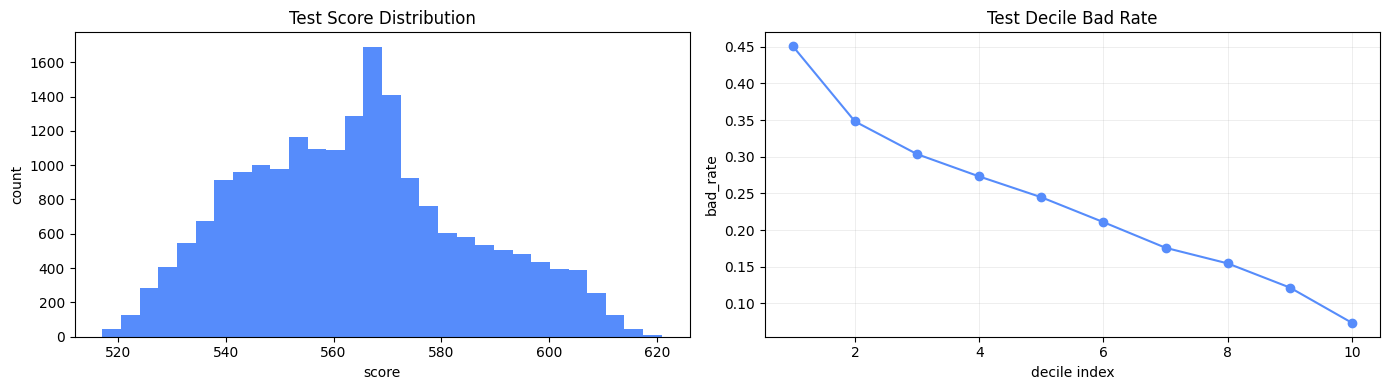

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_test
             ['score'], bins=30)
axes[0].set_title('Test Score Distribution')
axes[0].set_xlabel('score')
axes[0].set_ylabel('count')

axes[1].plot(test_decile.index + 1, test_decile['bad_rate'], marker='o')
axes[1].set_title('Test Decile Bad Rate')
axes[1].set_xlabel('decile index')
axes[1].set_ylabel('bad_rate')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()